In [21]:
from sedona.spark import SedonaContext
import os
from sedona.spark.maps.SedonaKepler import SedonaKepler

In [22]:
%%capture
bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder()

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext

In [23]:
spatial_df = sedona.\
    read.\
    format("geoparquet").\
    load(f"s3a://{bucket_name}/source_data/arizona_buildings")

roads_df = sedona.\
    read.\
    format("geoparquet").\
    load(f"s3a://{bucket_name}/source_data/arizona_roads")

# Kepler GL

In [4]:
import json
with open("kepler_map_config.json") as f:
    lines = f.readlines()
    data = "".join(lines)

config = json.loads(data)

map_view = SedonaKepler.create_map(spatial_df, "Sedona Buildings", config=config)

SedonaKepler.add_df(map_view, roads_df, "Sedona Roads")

/usr/local/lib/python3.10/dist-packages/keplergl/keplergl.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string
                                                                                

In [6]:
map_view

KeplerGl(config={'version': 'v1', 'config': {'visState': {'filters': [], 'layers': [{'id': '7tn4p83', 'type': …

# GeoPandas

In [7]:
import geopandas as gpd
import pyspark.sql.functions as f
import contextily as cx
from sedona.spark import dataframe_to_arrow

gdf = gpd.GeoDataFrame.from_arrow(dataframe_to_arrow(spatial_df))

In [ ]:
gdf = gdf.set_crs(crs="epsg:4326")

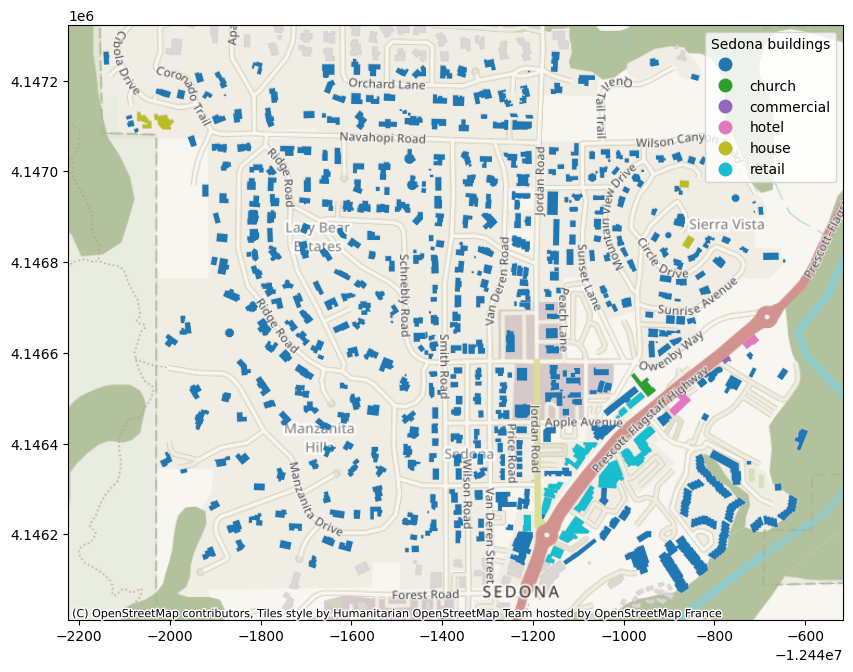

In [19]:
ax = gdf.to_crs(epsg=3857)\
    .plot(
        column="type",
        figsize=(10, 10),
        missing_kwds={
                "color": "lightgrey",
                "edgecolor": "red",
                "label": "Missing values",
            },
        legend=True,
        legend_kwds={"title": "Sedona buildings"},
    )



cx.add_basemap(ax)

# Interactive map

In [ ]:
gdf.explore(
        column="type",
        height=700,
        width=700,
        missing_kwds={
                "color": "lightgrey",
                "edgecolor": "red",
                "label": "Missing values",
            },
        legend=True,
        legend_kwds={"title": "Sedona buildings"},
)

# Pydeck

In [5]:
from sedona.spark.maps.SedonaPyDeck import SedonaPyDeck



In [6]:
crimes = sedona.read.format("geoparquet")\
    .load(f"s3a://{bucket_name}/source_data/crimes")\
    .selectExpr("id", "geom")

crimes.cache().count()

259173

In [39]:
heat_map = SedonaPyDeck.create_heatmap(
    crimes,
    aggregation="SUM",
    map_style="light",
    initial_view_state={
        "latitude": 41.8781,
        "longitude": -87.6298,
        "zoom": 14,
        "width": 500,
        "height": 500
    }
)


In [ ]:
heat_map.width = 800
heat_map.height = 600
heat_map.show()

## scatter plot map

In [ ]:
scatterplot_map = SedonaPyDeck.create_scatterplot_map(
    crimes,
    map_style="light",
    initial_view_state={
        "latitude": 41.8781,
        "longitude": -87.6298,
        "zoom": 14,
        "width": 500,
        "height": 500
    }
)

scatterplot_map.width = 800
scatterplot_map.height = 600
scatterplot_map.show()

# raster viz

In [26]:
from sedona.spark.raster_utils.SedonaUtils import SedonaUtils
from IPython.display import HTML, display

In [27]:
raster_df = sedona.read.format("binaryFile")\
    .load(f"s3a://{bucket_name}/source_data/raster_viz")\
    .selectExpr("RS_FromGeoTiff(content) AS rast")\
    .selectExpr("RS_AsPNG(rast)")

In [32]:
image_data = raster_df.head()[0]

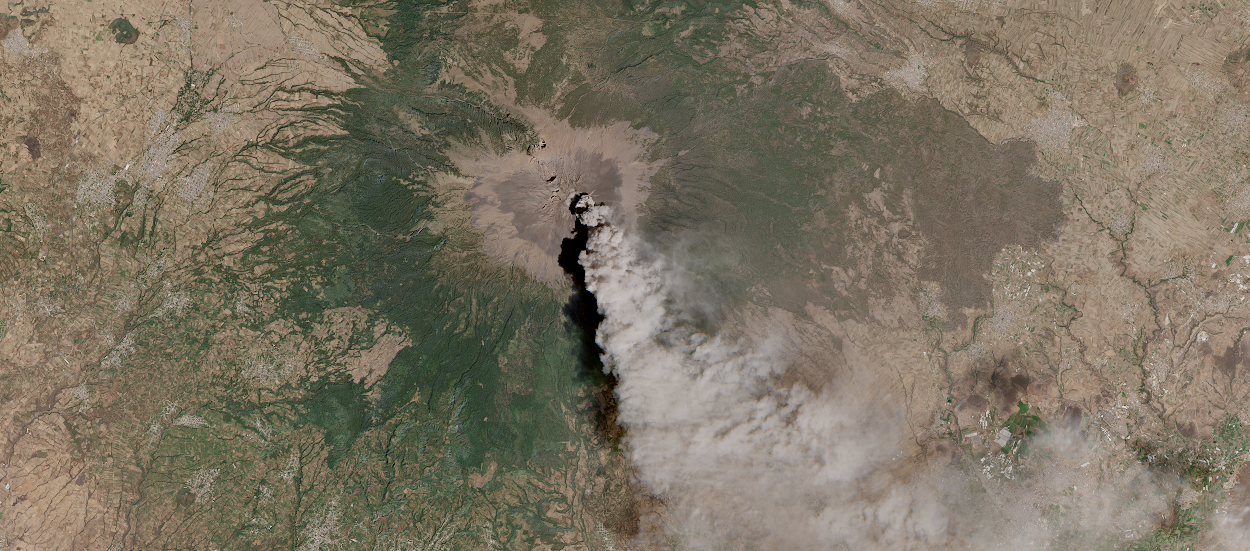

In [33]:
from IPython.display import Image, display

display(Image(image_data))